TensorFlow executing eagerly: True


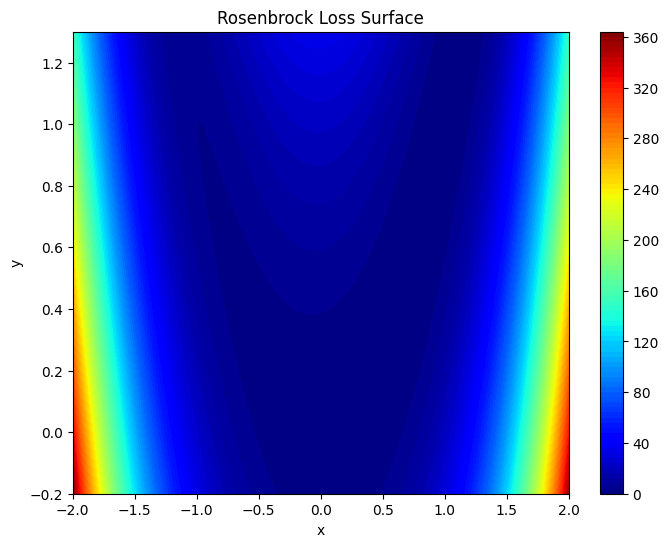

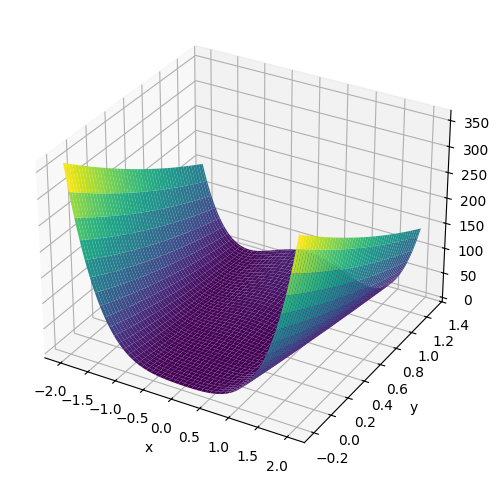

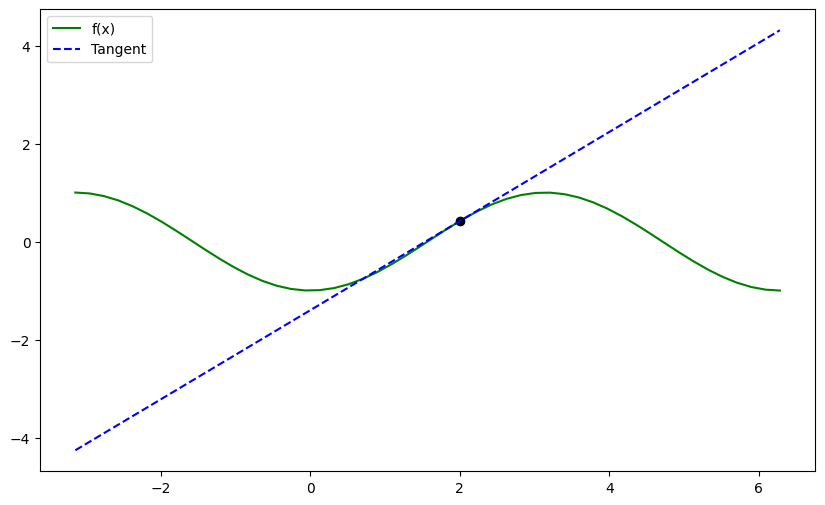

Optimized x: 0.7995811
Optimized y: 0.6348034


In [6]:
# Install (only if needed)
# !pip install tensorflow

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("TensorFlow executing eagerly:", tf.executing_eagerly())

# -------------------------------
# Rosenbrock Function
# -------------------------------
def rosenbrock_banana(x, y, a=1., b=20.):
    return (a - x) ** 2 + b * (y - x**2) ** 2


# -------------------------------
# Generate 2D Loss Surface
# -------------------------------
def gen_2d_loss_surface(loss_func, n_x=100, n_y=100,
                        min_x=-2., max_x=2.,
                        min_y=-0.2, max_y=1.3):

    x_vals = np.linspace(min_x, max_x, n_x)
    y_vals = np.linspace(min_y, max_y, n_y)

    X, Y = np.meshgrid(x_vals, y_vals)
    Z = loss_func(X, Y)

    return X, Y, Z


# -------------------------------
# Contour Plot
# -------------------------------
def make_contour_plot(X, Y, Z):
    plt.figure(figsize=(8, 6))
    plt.contourf(X, Y, Z, levels=100, cmap='jet')
    plt.colorbar()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Rosenbrock Loss Surface')
    plt.show()


# -------------------------------
# 3D Surface Plot
# -------------------------------
def make_surface_plot(X, Y, Z):
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    plt.show()


# -------------------------------
# Gradient Visualization
# -------------------------------
def f(x):
    return -np.cos(x)

def df(x, x0):
    return np.sin(x0) * (x - x0) + f(x0)


def interactive_gradient_visual(x0):
    x = np.linspace(-np.pi, 2 * np.pi)

    plt.figure(figsize=(10, 6))
    plt.plot(x, f(x), label="f(x)", color="green")
    plt.plot(x0, f(x0), 'o', color="black")

    plt.plot(x, df(x, x0), '--', label="Tangent", color="blue")

    plt.legend()
    plt.show()


# -------------------------------
# SGD Optimization
# -------------------------------
def SGD_update(params, grads, lr):
    for p, g in zip(params, grads):
        p.assign_sub(lr * g)


def optimize_banana(start_x, start_y, lr=0.01, epochs=100):

    x = tf.Variable(start_x, dtype=tf.float32)
    y = tf.Variable(start_y, dtype=tf.float32)

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            loss = rosenbrock_banana(x, y)

        grads = tape.gradient(loss, [x, y])
        SGD_update([x, y], grads, lr)

    print("Optimized x:", x.numpy())
    print("Optimized y:", y.numpy())


# -------------------------------
# MAIN EXECUTION
# -------------------------------
X, Y, Z = gen_2d_loss_surface(rosenbrock_banana)

make_contour_plot(X, Y, Z)
make_surface_plot(X, Y, Z)

interactive_gradient_visual(2.0)

optimize_banana(start_x=-1, start_y=0.7, lr=0.015, epochs=150)